# Assignment 2
* Student: **Danilo Tambone**
* NetID: **PWC25003**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install scikit-learn
from sklearn.preprocessing import PowerTransformer

# Set display options to show all columns
pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/Module 2/spotify-2023.csv', encoding='latin-1')

1.Read in the dataset.  How many rows and columns does it have?

---



In [3]:
df.shape

(953, 24)

The dataset contains 953 rows and 24 columns.

2. The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it. Hint: if needed, drop a row of problematic data to get it to convert properly.

In [4]:
# checking current dtype
df['streams'].dtype.name

'object'

In [5]:
# Turn bad values into NaNs
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Drop the rows that have NaNs in 'streams'
df = df.dropna(subset=['streams'])

# checking the new dtype
df['streams'].dtype.name

'float64'

In [6]:
# converting the dtype into 'int64'
df['streams'] = df['streams'].astype('int64')

3. Check the remaining variables. Do any other columns need their data type updated?



In [7]:
df.dtypes

,0
track_name,object
artist(s)_name,object
artist_count,int64
released_year,int64
released_month,int64
released_day,int64
in_spotify_playlists,int64
in_spotify_charts,int64
streams,int64
in_apple_playlists,int64


I noticed that 'in_shazam_chart' has a different dtype compared to 'in_apple_chart' or 'in_dezeer_chart'. The data inside are the same, numbers.
Additionaly, I noticed that months are separete from the year, so I can change that column as categorical variables.

In [8]:
# Looking for bad values in the shazam chart column
bad_shazam = pd.to_numeric(df['in_shazam_charts'], errors='coerce').isna()

# Show the unique bad values found
print(df[bad_shazam]['in_shazam_charts'].unique())

# In a second running attempt, the outcome will be emprty since I already changed the bad values

['1,021' '1,281' nan '1,173' '1,093' '1,133' '1,451' '1,170']


In [9]:
# Check if the column is currently text (object) before cleaning to avoid errors when re-running
if df['in_shazam_charts'].dtype == 'object':
  # removing the ','
  df['in_shazam_charts'] = df['in_shazam_charts'].str.replace(',', '')
  # removing the NaN values
  df = df.dropna(subset=['in_shazam_charts'])
  #converting into numbers
  df['in_shazam_charts'] = df['in_shazam_charts'].astype('int64')

In [10]:
# Change 'released_month' from int64 to object
df['released_month'] = df['released_month'].astype(str)
# Verify the datatype change
print(df['released_month'].dtypes)
# Display the head of the 'released_month' column to see the change
print(df['released_month'].head())

object
0    7
1    3
2    6
3    8
4    5
Name: released_month, dtype: object


4. Practice binning in_spotify_playlists. Show a histogram of the bins you made.


In [11]:
df['in_spotify_playlists']

,in_spotify_playlists
0,553
1,1474
2,1397
3,7858
4,3133
...,...
948,953
949,1180
950,573
951,1320


Before creating bins for the in_spotify_playlists column, I will visualize the data with a histogram. This will allow me to observe the distribution of the values and choose meaningful ranges for the categories.

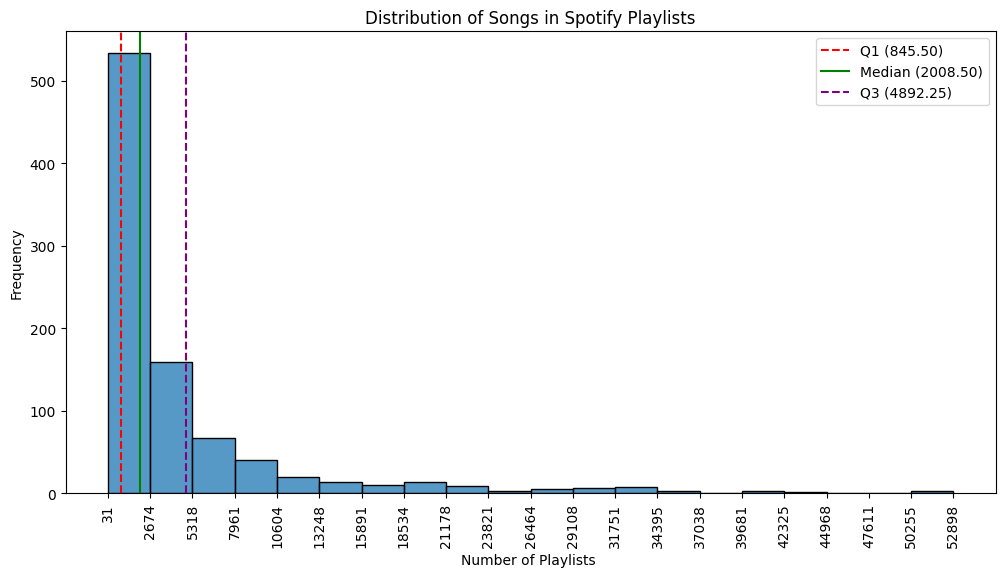

In [12]:
# show a histogram of the column with quartiles to get an idea of bin size
plt.figure(figsize=(12, 6))
counts, bin_edges = np.histogram(df['in_spotify_playlists'], bins=20)
# Create the histogram
sns.histplot(data=df, x='in_spotify_playlists', bins=bin_edges)
plt.xticks(bin_edges, rotation=90) # Rotation 90 makes them vertical so they don't overlap

plt.title('Distribution of Songs in Spotify Playlists')
plt.xlabel('Number of Playlists ')
plt.ylabel('Frequency')

# Calculate the quartiles
q1 = df['in_spotify_playlists'].quantile(0.25)
q2 = df['in_spotify_playlists'].quantile(0.50) # Median
q3 = df['in_spotify_playlists'].quantile(0.75)

# Add vertical lines for the quartiles
plt.axvline(q1, color='red', linestyle='--', label=f'Q1 ({q1:.2f})')
plt.axvline(q2, color='green', linestyle='-', label=f'Median ({q2:.2f})')
plt.axvline(q3, color='purple', linestyle='--', label=f'Q3 ({q3:.2f})')

# Add a legend to show the labels for the lines
plt.legend()

plt.show()

Since the in_spotify_playlists column represents the number of times a song appears in a playlist, I will categorize the songs into three bins based on teh chart informations to reflect their popularity:

Not popular: Minimum to 2674

Popular: 2675 to 5318

Very popular: 5319 to max

   in_spotify_playlists  Playlist_Bin
0                   553   not popular
1                  1474   not popular
2                  1397   not popular
3                  7858  very popular
4                  3133       popular

Distribution of Playlist Bins:
Playlist_Bin
not popular     533
very popular    210
popular         159
Name: count, dtype: int64


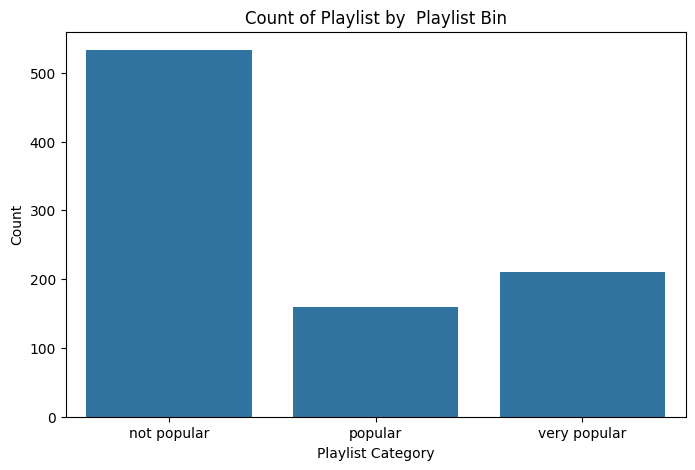

In [13]:
# Binning the column into ranges for 'not popular', 'popular' and 'very popular'
# Define the bin edges and labels
bins = [0, 2674, 5318, df['in_spotify_playlists'].max()]
labels = ['not popular', 'popular', 'very popular']

# Create a new column 'Playlist_Bin' by binning the 'in_spotify_playlists' column
df['Playlist_Bin'] = pd.cut(df['in_spotify_playlists'], bins=bins, labels=labels, right=True)

# Display the first few rows with the new column
print(df[['in_spotify_playlists', 'Playlist_Bin']].head())

# Display the distribution of the new 'Playlist_Bin' column
print("\nDistribution of Playlist Bins:")
print(df['Playlist_Bin'].value_counts())

# Optionally, visualize the distribution of the new bin
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Playlist_Bin', order=labels)
plt.title('Count of Playlist by  Playlist Bin')
plt.xlabel('Playlist Category')
plt.ylabel('Count')

plt.show()

5. Find the missing values in the dataset and handle them appropriately. Which column(s) had the most missing values?


In [14]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

Missing values per column:
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts         0
bpm                      0
key                     86
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
Playlist_Bin             0
dtype: int64

Total missing values in the dataset:
86


The only column with missing values is the 'key' column, counting 86 missing values. Considering the categorical meaning of the variable I will use the mode to impute a resonable value.

In [15]:
# Update the missing values in the key column using imputation
mode_key = df['key'].mode()[0] # Calculate the mode and taking the first value
print(f"Imputing missing key values with the mode: {mode_key:}")
df['key'].fillna(mode_key, inplace=True)

# Verify that the missing values in 'key' have been filled
print("\nMissing values after filling missing key:")
print(df.isnull().sum())

Imputing missing key values with the mode: C#

Missing values after filling missing key:
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
Playlist_Bin            0
dtype: int64


/tmp/ipython-input-616691862.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['key'].fillna(mode_key, inplace=True)


6. Find the potential outliers in the dataset and handle them appropriately. What artist(s) are associated with the most extreme outliers?

In [16]:
## Detecting Outliers in All Numeric Columns

# Select only the numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Iterate through each numeric column to find outliers
for col in numeric_cols:
    print(f"Checking for outliers in column: {col}")

    # calculate interquartile range (IQR)
    q1 = df[col].quantile(0.1)
    q3 = df[col].quantile(0.9)
    iqr = q3 - q1

    # define the boundaries for an outlier
    lower_bound = q1 - (3 * iqr)
    upper_bound = q3 + (3 * iqr)

    # find the outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # display the outliers for the current column
    if not outliers.empty:
        print(f"Outliers found in {col}: {len(outliers)} outliers")
        # Display only the outlier values from the current column
        print(outliers[col])
    else:
        print(f"No outliers found in {col} using the quantile range method.")
    print("-" * 30) # Separator for clarity between columns

Checking for outliers in column: artist_count
No outliers found in artist_count using the quantile range method.
------------------------------
Checking for outliers in column: released_year
Outliers found in released_year: 22 outliers
80     1975
195    1968
425    1973
439    1930
447    1963
448    1959
451    1970
454    1963
457    1971
459    1952
460    1946
461    1979
466    1950
469    1942
471    1963
476    1958
483    1959
495    1958
496    1957
717    1975
840    1982
922    1982
Name: released_year, dtype: int64
------------------------------
Checking for outliers in column: released_day
No outliers found in released_day using the quantile range method.
------------------------------
Checking for outliers in column: in_spotify_playlists
Outliers found in in_spotify_playlists: 4 outliers
624    49991
630    51979
720    50887
757    52898
Name: in_spotify_playlists, dtype: int64
------------------------------
Checking for outliers in column: in_spotify_charts
Outliers fo

Upon reviewing the statistical outliers detected by the IQR method, I observed the following:

*   Popularity Metrics (Playlists & Charts): The outliers found in columns like in_spotify_playlists, in_shazam_charts, and in_deezer_charts do not appear to be data errors. Instead, they represent "Hits"—songs that have achieved extreme popularity and viral success. Since the goal of the next analysis is to identify artists associated with extreme values, these data points are valid and crucial for our insights.
*   Instrumentalness: The instrumentalness_% column flagged a large number of outliers (84). This suggests that the distribution is naturally skewed (likely separating instrumental tracks from vocal tracks) rather than containing anomalies. Therefore, I will not treat these as outliers to be removed.

*   Released Year: The outliers flagged in the released_year column correspond to older tracks (e.g., from the 1950s, 60s, or 70s). These are valid release dates representing the historical range of the library, not data entry errors. Therefore, they will be retained to preserve the dataset's temporal diversity.





Conclusion: I will retain the extreme values in the popularity columns as they are true signals of success, which are necessary to answer the question regarding artists associated with the most extreme outliers.



In [17]:
# Recalculate the boundary specifically for 'in_spotify_playlists'
q1 = df['in_spotify_playlists'].quantile(0.10)
q3 = df['in_spotify_playlists'].quantile(0.90)
iqr = q3 - q1
spotify_upper_bound = q3 + (3 * iqr)

# Filter the dataframe to find the outliers
extreme_outliers = df[df['in_spotify_playlists'] > spotify_upper_bound]

# 3. Print only the Artist Name and the Playlist Count
print("Artists associated with the most extreme outliers:")
print(extreme_outliers[['artist(s)_name', 'in_spotify_playlists']])

Artists associated with the most extreme outliers:
                                 artist(s)_name  in_spotify_playlists
624                                     Nirvana                 49991
630                                 The Killers                 51979
720                                      Avicii                 50887
757  Pharrell Williams, Nile Rodgers, Daft Punk                 52898


7. Practice standardizing in_spotify_playlists.

   in_spotify_playlists  I.S.P._Standardized
0                   553            -0.557758
1                  1474            -0.436804
2                  1397            -0.446916
3                  7858             0.401605
4                  3133            -0.218928


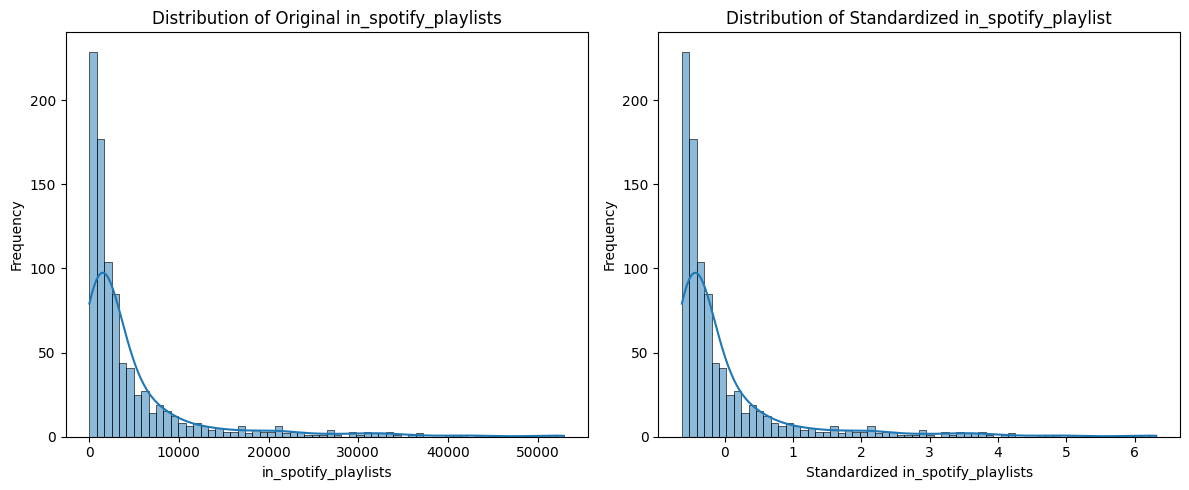

In [18]:
# Standardize the 'in_spotify_playlists' column using Z-scores
df['I.S.P._Standardized'] = (df['in_spotify_playlists'] - df['in_spotify_playlists'].mean()) / df['in_spotify_playlists'].std()

# Display the head with the original and standardized KM columns
print(df[['in_spotify_playlists', 'I.S.P._Standardized']].head())

# Optionally, visualize the distribution of the original and standardized KM
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original in_spotify_playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data=df, x='I.S.P._Standardized', kde=True)
plt.title('Distribution of Standardized in_spotify_playlist')
plt.xlabel('Standardized in_spotify_playlists')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

   in_spotify_playlists  I.S.P._Standardized  I.S.P._Scaled
0                   553            -0.557758       0.009874
1                  1474            -0.436804       0.027295
2                  1397            -0.446916       0.025838
3                  7858             0.401605       0.148051
4                  3133            -0.218928       0.058676


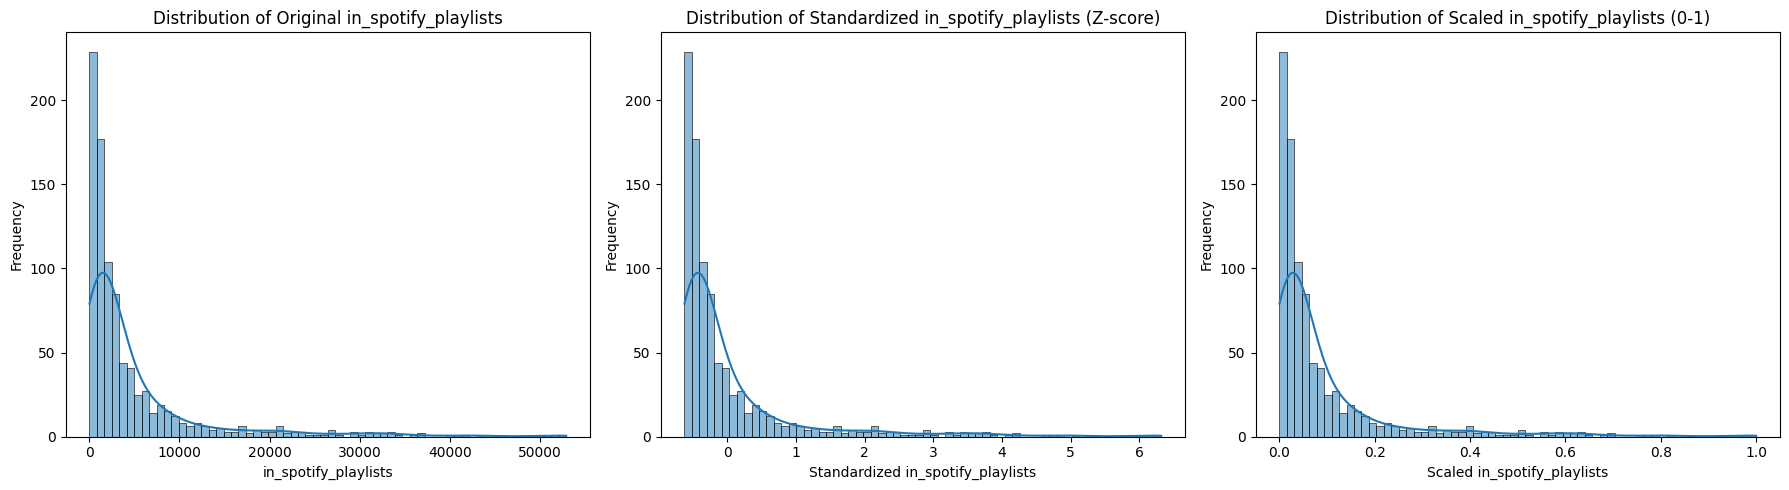

In [19]:
# Standardize the 'in_spotify_playlists' column using Min-Max scaling (0 to 1 scale)
df['I.S.P._Scaled'] = (df['in_spotify_playlists'] - df['in_spotify_playlists'].min()) / (df['in_spotify_playlists'].max() - df['in_spotify_playlists'].min())

# Display the head with the original, standardized, and scaled in_spotify_playlists columns
print(df[['in_spotify_playlists', 'I.S.P._Standardized', 'I.S.P._Scaled']].head())

# Optionally, visualize the distribution of the original, standardized, and scaled I.S.P
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original in_spotify_playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.histplot(data=df, x='I.S.P._Standardized', kde=True)
plt.title('Distribution of Standardized in_spotify_playlists (Z-score)')
plt.xlabel('Standardized in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.histplot(data=df, x='I.S.P._Scaled', kde=True)
plt.title('Distribution of Scaled in_spotify_playlists (0-1)')
plt.xlabel('Scaled in_spotify_playlists')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

8. Practice transforming in_spotify_playlists. How does this differ from standardizing?


   in_spotify_playlists  ISP_JohnsonSU
0                   553      -1.011812
1                  1474      -0.249508
2                  1397      -0.290847
3                  7858       1.017690
4                  3133       0.326763


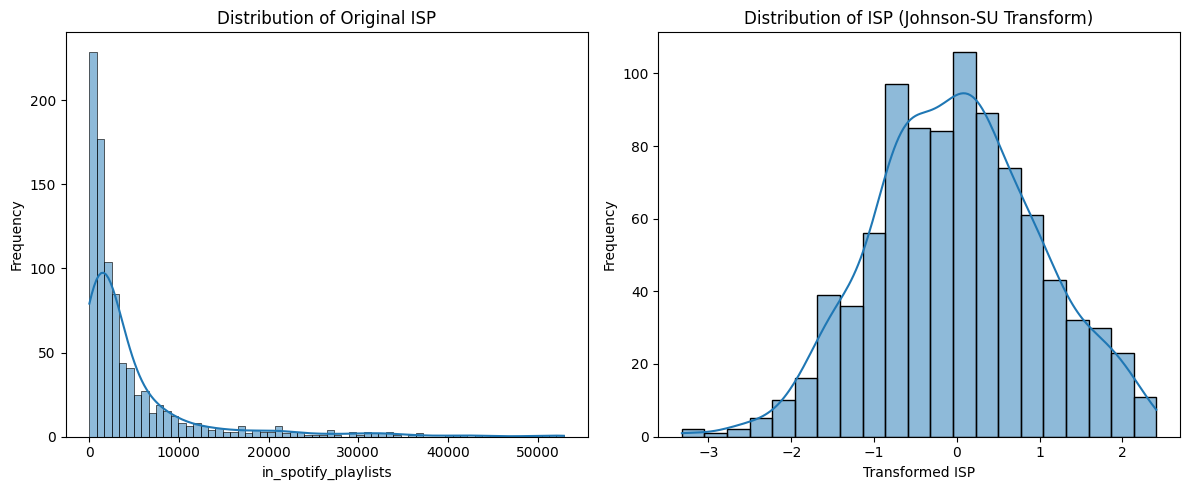

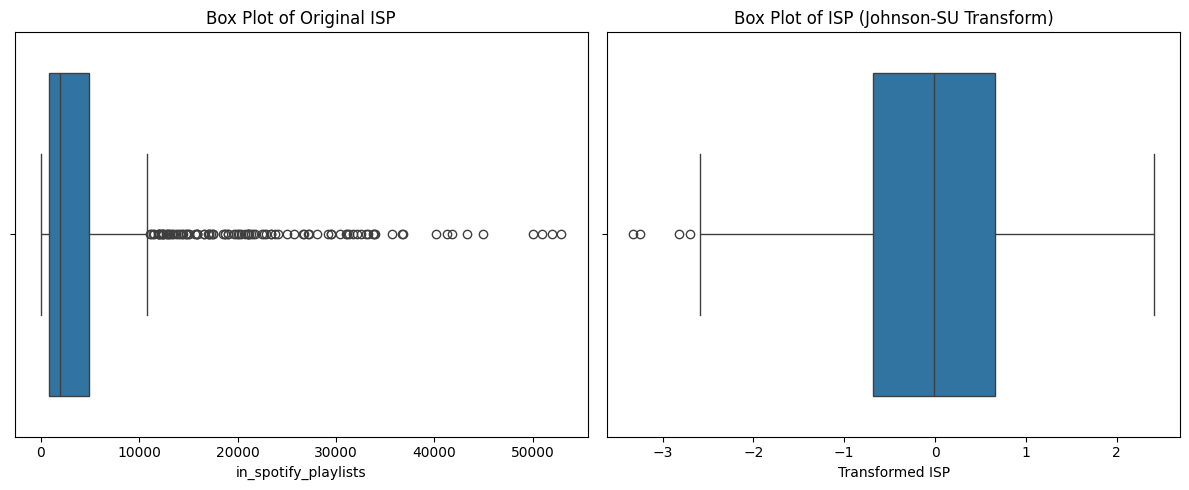

In [20]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Reshape the data to be a 2D array (required by transform)
ISP_reshaped = df['in_spotify_playlists'].values.reshape(-1, 1)

# Fit the transformer and transform the 'I.S.P' column
df['ISP_JohnsonSU'] = pt.fit_transform(ISP_reshaped)

print(df[['in_spotify_playlists', 'ISP_JohnsonSU']].head())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original ISP')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data=df, x='ISP_JohnsonSU', kde=True)
plt.title('Distribution of ISP (Johnson-SU Transform)')
plt.xlabel('Transformed ISP')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='in_spotify_playlists')
plt.title('Box Plot of Original ISP')
plt.xlabel('in_spotify_playlists')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='ISP_JohnsonSU')
plt.title('Box Plot of ISP (Johnson-SU Transform)')
plt.xlabel('Transformed ISP')

plt.tight_layout()
plt.show()

Standardizing and Transforming are both ways to change data, but they have different goals and results:


*   Standardizing changes the range of the numbers, but it keeps the original shape. If the data is skewed before standardizing, it will still be skewed after. It does not fix the distribution.
*   Transforming changes the shape of the distribution. It does this by "squashing" the long tail of outliers and stretching the rest to fit a normal distribution. That is why the resultant histogram looked completely different after the transformation, and the outliers are now in the "negative" zone of the box-plot.





9. Perform data reduction on the key variable. How many categories did you reduce it to?


In [21]:
# Group by 'key' and calculate statistics based on a numeric column (like in_spotify_playlists)
key_summary = df.groupby('key')['in_spotify_playlists'].agg(['count', 'mean', 'median', 'std']).reset_index()

# Rename columns
key_summary.columns = ['key', 'Count', 'Mean Playlists', 'Median Playlists', 'Std Dev']

# Sort by Mean to see which keys are similar
key_summary_sorted = key_summary.sort_values(by='Mean Playlists', ascending=True)

# Display
print("Summary Table of Playlist counts by Key:")
print(key_summary_sorted)

Summary Table of Playlist counts by Key:
   key  Count  Mean Playlists  Median Playlists       Std Dev
0    A     70     3083.014286            1692.0   4504.800227
2    B     77     4177.142857            1796.0   6736.195562
10  G#     85     4315.682353            2096.0   6362.877515
7    F     87     4408.632184            1584.0   6961.586868
9    G     91     4508.956044            1950.0   7326.859321
1   A#     55     4716.327273            2790.0   6246.325747
6    E     59     4757.661017            2264.0   6118.963775
8   F#     69     5329.724638            1267.0  10284.710818
4    D     78     5504.333333            2544.0   8502.032042
3   C#    201     5528.766169            1945.0   8805.506302
5   D#     30     6099.600000            2648.0   8206.071237


In [22]:
# 1. Define the mapping dictionary based on the Median groups
key_mapping = {
    'F#': 'Low Popularity',
    'F':  'Low Popularity',
    'A':  'Low Popularity',

    'B':  'Medium Popularity',
    'C#': 'Medium Popularity',
    'G':  'Medium Popularity',
    'G#': 'Medium Popularity',

    'E':  'High Popularity',
    'D':  'High Popularity',
    'D#': 'High Popularity',
    'A#': 'High Popularity'
}

# 2. Apply the mapping to create a new column
df['key_category'] = df['key'].map(key_mapping)

# 3. Check the results
print("New Category Counts:")
print(df['key_category'].value_counts())

# 4. Verify with a new summary table
new_summary = df.groupby('key_category')['in_spotify_playlists'].agg(['count', 'mean', 'median']).sort_values(by='median')
print("\nStats by New Category:")
print(new_summary)

New Category Counts:
key_category
Medium Popularity    454
Low Popularity       226
High Popularity      222
Name: count, dtype: int64

Stats by New Category:
                   count         mean  median
key_category                                 
Low Popularity       226  4279.261062  1568.5
Medium Popularity    454  4867.995595  1959.0
High Popularity      222  5191.108108  2593.5


I reduced the key variable from 11 distinct keys down to 3 categories:

Low Popularity
Medium Popularity
High Popularity

Since the popularity data (in_spotify_playlists) is highly skewed by "Hits," I used the median playlist count rather than the mean to determine the typical success of each key. I then grouped the keys with similar median values together to create three balanced categories (Low, Medium, and High)

10. Practice making dummy variables for the new simplified key column. How many dummy variables did you make and why?

In [23]:
# Make dummy variables for the 'key' column
# Create dummy variables
key_dummies = pd.get_dummies(df['key_category'], drop_first=True, dtype=float)

# Rename columns
key_dummies.columns = [f'key_category_{col}' for col in key_dummies.columns]

# Concatenate the original DataFrame with the new dummy variables DataFrame
df = pd.concat([df, key_dummies], axis=1)

# Display the first few rows
print(df.head())

# Display the columns to see the original and new dummy variables
print("\nColumns after creating dummy variables for key:")
df.columns

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year released_month  released_day  in_spotify_playlists  \
0           2023              7            14                   553   
1           2023              3            23                  1474   
2           2023              6            30                  1397   
3           2019              8            23                  7858   
4           2023              5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  in_apple_charts  \
0                147  141381703                  43     

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
       'Playlist_Bin', 'I.S.P._Standardized', 'I.S.P._Scaled', 'ISP_JohnsonSU',
       'key_category', 'key_category_Low Popularity',
       'key_category_Medium Popularity'],
      dtype='object')

I created 2 dummy variables for the 3 categories. I did not create a third variable to avoid redundancy. If both dummy variables are 0, the model understands the song belongs to the High Popularity group.
I followed a simple rule=
Number dummy = Number of categories - 1

11. Perform PCA on bpm, danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%. How many principal components would you retain and why?

Correlation Matrix for PCA Variables:


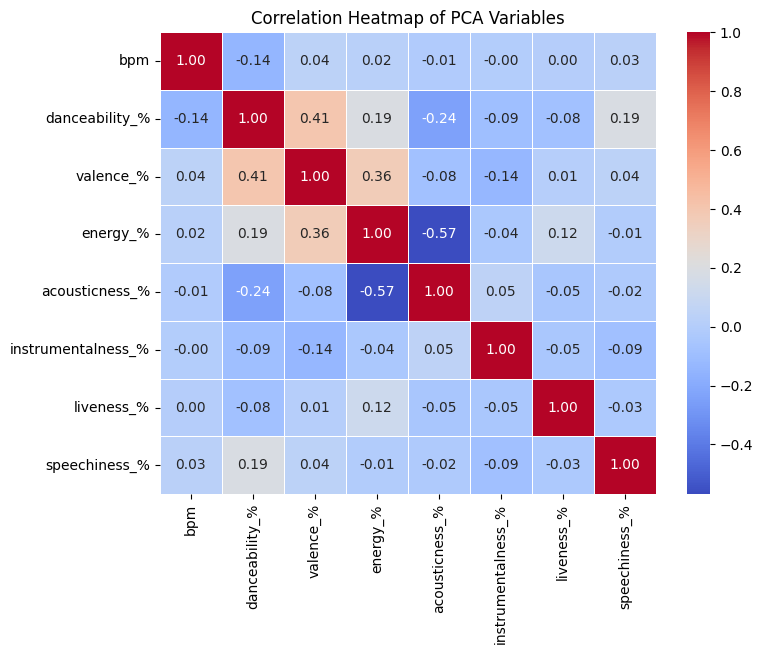

In [24]:
# Check correlations
# Select the columns for PCA
pca_cols = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_pca = df[pca_cols]

# Calculate the correlation matrix
correlation_matrix = df_pca.corr()

# Display the correlation matrix
print("Correlation Matrix for PCA Variables:")


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of PCA Variables')
plt.show()

Explained variance ratio by each principal component:
[0.24750583 0.15548034 0.13255169 0.12634286 0.11782182 0.10817805
 0.07330919 0.03881023]

Cumulative explained variance ratio:
[0.24750583 0.40298616 0.53553785 0.66188072 0.77970254 0.88788058
 0.96118977 1.        ]


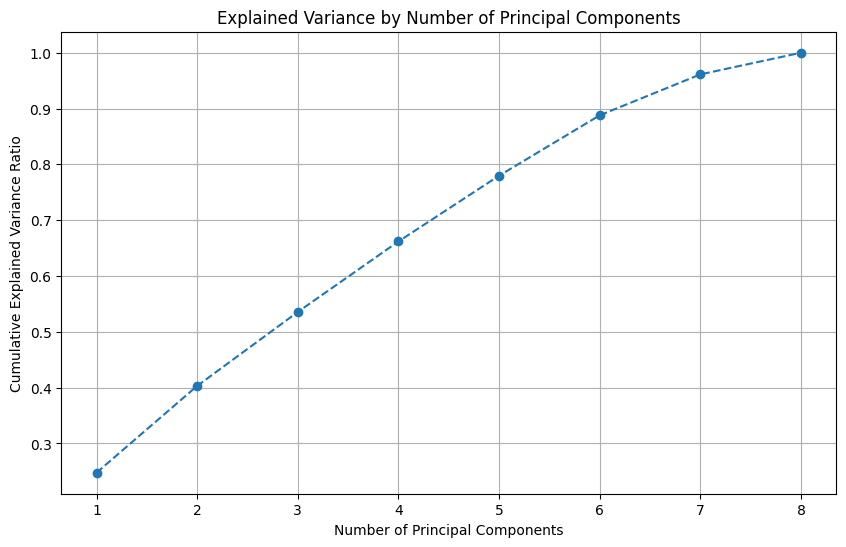


PCA Loadings (Component direction in original feature space):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
bpm,-0.022226,-0.220112,0.669428,-0.606921,-0.188188,0.075900,0.294139,0.082932
danceability_%,0.451727,0.441354,-0.196323,0.001842,-0.035519,0.174297,0.660641,0.307435
valence_%,0.459345,0.222017,0.101291,0.000401,-0.550754,0.329009,-0.339120,-0.450413
energy_%,0.552208,-0.364951,-0.048625,-0.076182,0.030396,-0.050882,-0.418078,0.612705
acousticness_%,-0.482211,0.361978,0.133116,0.144045,-0.352119,0.321159,-0.237550,0.560727
instrumentalness_%,-0.165959,-0.242210,-0.521210,-0.450898,0.112784,0.650126,-0.017797,-0.055873
liveness_%,0.065145,-0.415858,0.319326,0.616838,0.150933,0.522809,0.208740,-0.026014
speechiness_%,0.123304,0.460049,0.330682,-0.145922,0.706810,0.232137,-0.294831,-0.045971


In [25]:
# Perform PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Select the features for PCA
df_pca = df[pca_features]

# Standardize the data before applying PCA
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

# Apply PCA
pca = PCA()
df_pca_transformed = pca.fit_transform(df_pca_scaled)

# Create a DataFrame with the principal components
pca_columns = [f'PC{i+1}' for i in range(df_pca_transformed.shape[1])]
df_pca_components = pd.DataFrame(df_pca_transformed, columns=pca_columns, index=df_pca.index)

# Display the explained variance ratio for each principal component
print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)

# Display the cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance ratio:")
print(cumulative_variance_ratio)

# Optionally, visualize the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.title('Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance_ratio) + 1))
plt.show()

# Display the PCA loadings (coefficients for each original feature in each component)
# This helps in understanding what each principal component represents
print("\nPCA Loadings (Component direction in original feature space):")
pca_loadings = pd.DataFrame(pca.components_.T, columns=pca_columns, index=pca_features)
pca_loadings

I would retain 6 Principal Components.
Looking at the cumulative explained variance, the first 6 components capture approximately 90% of the total information in the dataset. By selecting 6, we achieve a high-fidelity representation of the original data, ensuring that we remove noise and redundancy without losing significant musical characteristics.